# MODEL 04 — max-tier ceiling & prediction intervals

The models so far predict `log_aav_cap_share` with a linear model and tree
ensembles. This notebook attacks two things they ignore:

**Part A — the max-tier ceiling.** The CBA caps a player's *year-1 salary* at a
percentage of the cap by tenure class (`max_tier_pct`: 25% / 30% / 35%).
Multi-year max deals include 8% annual raises, so the AAV legitimately exceeds
the year-1 tier — the ceiling on AAV is `max_tier_aav_pct` (e.g. ~29% for a
5-year 25% deal). A max deal is therefore **right-censored** — the star's true
market value is *at least* what the cap allows.

Defining the censored set requires care. An absolute band (e.g. AAV within 5
percentage points of the tier) is too broad — it admits deals paying 80–85% of
their tier, which are ordinary deals, not cap-bound. Instead we use a
**relative** band: a deal is cap-bound if its AAV falls within 3% of the AAV
ceiling (`aav / tier_aav ∈ [0.97, 1.00]`). This yields **22 censored deals**
(15 train, 4 val, 3 test) — all legitimate max-contract stars. The set is
small but sufficient for a Tobit MLE.

A **two-stage Heckman** selection correction was considered but **declined**.
With only 15 censored train rows against 59+1 regressors the Probit is
**near-separated**: the MLE drives the log-likelihood toward 0, the Hessian
fails to invert, and the inverse-Mills ratio is NaN on separated rows — so
the stage-1 standard errors (and any ρσ / p-value) are **unavailable**.
No selection-corrected coefficients or significance claim is reported (A4).

The Tobit MLE (manual likelihood, L-BFGS-B) reports the **latent** prediction
(de-censored) and the conditional observed expectation. We fit on train and
compare against `linear_interpretable`.

**Part B — prediction intervals.** `QuantileRegressor` at τ ∈ {0.10, 0.50,
0.90} on the same canonical features. The L1 penalty `alpha` is tuned per
quantile with the **walk-forward** protocol (pinball loss on train-only folds,
identical to MODEL 03), so val/test never influence tuning. Intervals are
evaluated on `val` by pinball loss, [q10, q90] **coverage**, and width — and
benchmarked against a symmetric residual-based interval from `gb_tuned`.

Protocol (unchanged): fits on **train only**, `val` = headline, `test` =
hold-out context; models registered into `data/model/results.csv`.

Features: `controls` + `chosen_stats` from `data/model/linear_features.json`
(**47 features**).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import QuantileRegressor, LinearRegression

PROJECT_ROOT = Path("..")
PREP_CSV = PROJECT_ROOT / "data" / "model" / "prep.csv"
RESULTS_CSV = PROJECT_ROOT / "data" / "model" / "results.csv"
PRED_LINEAR_CSV = PROJECT_ROOT / "data" / "model" / "predictions_linear.csv"
PRED_ENSEMBLE_CSV = PROJECT_ROOT / "data" / "model" / "predictions_ensemble.csv"
PRED_QUANTILE_CSV = PROJECT_ROOT / "data" / "model" / "predictions_quantile.csv"
INTERVAL_JSON = PROJECT_ROOT / "data" / "model" / "interval_metrics.json"
FEATURES_JSON = PROJECT_ROOT / "data" / "model" / "linear_features.json"

prep = pd.read_csv(PREP_CSV)
TARGET = "log_aav_cap_share"
y = prep[TARGET]
masks = {s: prep["split"].eq(s) for s in ("train", "val", "test")}

feat_meta = json.load(open(FEATURES_JSON))
FEATS = feat_meta["controls"] + feat_meta["chosen_stats"]
print("features:", len(FEATS), "=", len(feat_meta["controls"]), "controls +",
      len(feat_meta["chosen_stats"]), "stats")

CEILING_TOL = 0.03          # relative band: aav within 3% below AAV ceiling = cap-bound
QUANTILES = [0.10, 0.50, 0.90]

X_train = prep.loc[masks["train"], FEATS].reset_index(drop=True)
y_train = y[masks["train"]].reset_index(drop=True)

sc = StandardScaler().fit(X_train)                 # fit on train only
Xs_train = pd.DataFrame(sc.transform(X_train), columns=FEATS)
Xs = pd.DataFrame(sc.transform(prep[FEATS]), columns=FEATS)
print("split sizes:", {s: int(m.sum()) for s, m in masks.items()})

features: 60 = 36 controls + 24 stats
split sizes: {'train': 906, 'val': 216, 'test': 242}


## Part A — the max-tier ceiling

### A1. Ceiling landscape

Classification of every deal against its CBA AAV ceiling (`max_tier_aav_pct`).
`at_ceiling` identifies **pay bound by the cap**: AAV within 3% *relative*
of the ceiling (`0 ≤ (tier_aav − aav) / tier_aav ≤ 0.03`). An absolute
band would admit deals at 80–85% of their tier — those are ordinary deals,
not cap-bound. The relative band yields 22 censored deals (15 train, 4 val,
3 test), all max-contract stars.

In [2]:
prep["aav"] = np.exp(prep[TARGET])
tier_aav = prep["max_tier_aav_pct"]
gap_abs = tier_aav - prep["aav"]
gap_rel = gap_abs / tier_aav     # relative gap (fraction of ceiling)
prep["at_ceiling"] = gap_rel.between(0, CEILING_TOL)   # right-censored: AAV within 3% below ceiling
prep["above_tier"] = gap_abs.lt(0) & gap_abs.abs().le(tier_aav * 0.05)  # supermax raises, uncensored
limits = np.log(tier_aav.to_numpy())                    # censoring limit (log AAV ceiling)

print(f"censored set (aav/tier_aav in [1-{CEILING_TOL:.0%}, 1.00]):"
      f" {int(prep['at_ceiling'].sum())} total",
      {s: int(prep.loc[masks[s], 'at_ceiling'].sum()) for s in ('train', 'val', 'test')})
print("tier mix of censored:", prep.loc[prep["at_ceiling"], "max_tier_pct"].value_counts().sort_index().to_dict())
print("supermax deals:", int(prep["supermax"].sum()),
      "| censored & supermax:", int((prep["at_ceiling"] & prep["supermax"].eq(1)).sum()))
print("mean target (train), censored vs rest:",
      prep.loc[masks["train"]].groupby("at_ceiling")[TARGET].mean().round(3).to_dict())
print("val+test censored players:", prep.loc[prep["at_ceiling"] & ~masks["train"], "player_name"].tolist())

censored set (aav/tier_aav in [1-3%, 1.00]): 22 total {'train': 15, 'val': 4, 'test': 3}
tier mix of censored: {0.25: 7, 0.3: 8, 0.35: 7}
supermax deals: 23 | censored & supermax: 3
mean target (train), censored vs rest: {False: -3.0, True: -1.113}
val+test censored players: ['Jaylen Brown', 'LeBron James', 'LeBron James', 'Nikola Jokić', 'Tyrese Maxey', 'Pascal Siakam', 'Fred VanVleet']


### A2. Does the final linear model under-predict the ceiling?

Residuals of `linear_interpretable` (from `predictions_linear.csv`) grouped by
`at_ceiling`. A negative mean residual on the ceiling deals would mean the model
systematically pays stars below what the cap lets them earn — the bias the
censored models should remove.

linear_interpretable residual diagnostics — train:
            count    mean  median     std    rmse
at_ceiling                                       
False         891 -0.0046  0.0016  0.5106  0.5104
True           15  0.2745  0.2969  0.4432  0.5086

— val:
            count    mean  median     std    rmse
at_ceiling                                       
False         212 -0.0718 -0.0849  0.4640  0.4684
True            4  0.0614  0.0455  0.6097  0.5316


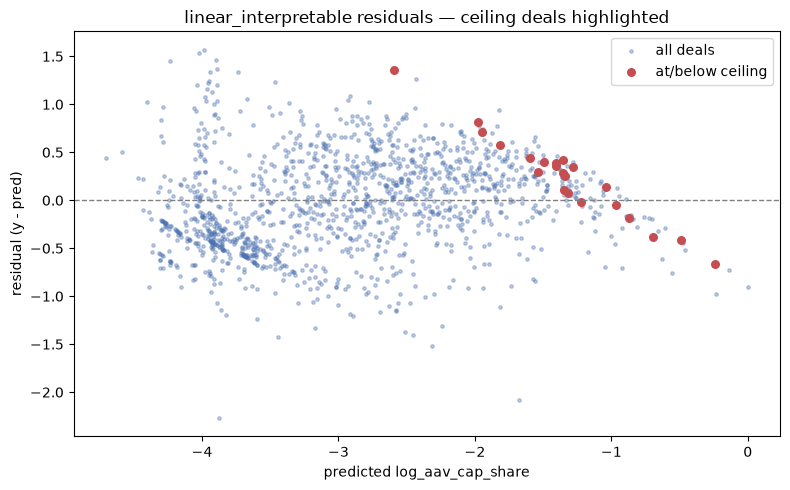

In [3]:
pl = pd.read_csv(PRED_LINEAR_CSV)
lin_pred = pl["linear_interpretable"]
resid = y - lin_pred

def resid_table(subset):
    d = pd.DataFrame({"at_ceiling": prep["at_ceiling"][subset],
                      "resid": resid[subset], "y": y[subset]})
    t = d.groupby("at_ceiling")["resid"].agg(["count", "mean", "median", "std"])
    t["rmse"] = d.groupby("at_ceiling").apply(
        lambda g: float(np.sqrt(np.mean(g["resid"] ** 2))), include_groups=False)
    return t.round(4)

print("linear_interpretable residual diagnostics — train:")
print(resid_table(masks["train"]).to_string())
print("\n— val:")
print(resid_table(masks["val"]).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(lin_pred, resid, s=6, alpha=0.35, color="#4C72B0", label="all deals")
ax.scatter(lin_pred[prep["at_ceiling"]], resid[prep["at_ceiling"]], s=30,
           color="#C44E52", label="at/below ceiling")
ax.axhline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("predicted log_aav_cap_share")
ax.set_ylabel("residual (y - pred)")
ax.set_title("linear_interpretable residuals — ceiling deals highlighted")
ax.legend()
fig.tight_layout()
plt.show()

### A3. Censored regression (Tobit MLE)

The ceiling is a variable, tenure-dependent cap: deal *i* has limit
`L_i = log(max_tier_aav_pct)` and we observe `Y_i = min(Y_i*, L_i)`. With
`Y* ~ N(b0 + Xβ, σ²)` (features are standardized, so an intercept term is
required) the log-likelihood is

- uncensored rows: `log φ((y - b0 - Xβ)/σ) - log σ`
- censored rows:  `log Φ((b0 + Xβ - L)/σ)`

Maximized with `scipy.optimize.minimize` (L-BFGS-B, started from the OLS
solution including its intercept). Predictions come in two flavours: the
**latent** expectation `b0 + Xβ` (de-censored — what stars would command without
the cap) and the conditional **observed** expectation
`E[Y] = Φ(m)·μ - σ·φ(m) + L·(1 - Φ(m))` with `μ = b0 + Xβ`, `m = (L - μ)/σ`.
`tobit_ceiling` is registered on the observed expectation so RMSE is comparable
to the linear model.

In [4]:
cens = prep["at_ceiling"].to_numpy()
Xtr = Xs_train.to_numpy()
ytr = y_train.to_numpy()
ctr = cens[masks["train"].to_numpy()]
ltr = limits[masks["train"].to_numpy()]


def neg_ll(params, X, yy, c, L):
    b0, beta, log_sigma = params[0], params[1:-1], params[-1]
    sigma = np.exp(log_sigma)
    mu = b0 + X @ beta
    z = (yy - mu) / sigma
    ll = np.where(c == 0, norm.logpdf(z) - log_sigma, norm.logcdf((mu - L) / sigma))
    return -ll.sum()


ols_linear = LinearRegression().fit(Xtr, ytr)
init = np.concatenate([np.array([ols_linear.intercept_]), ols_linear.coef_,
                       [np.log(float(np.std(ytr - ols_linear.predict(Xtr))))]])
print("neg-LL at OLS init:", round(neg_ll(init, Xtr, ytr, ctr, ltr), 3))

mle = minimize(neg_ll, init, args=(Xtr, ytr, ctr, ltr), method="L-BFGS-B",
               options={"maxiter": 5000})
print("tobit converged:", mle.success, "| final neg-LL:", round(mle.fun, 3))
b0_tobit = mle.x[0]
beta_tobit = mle.x[1:-1]
sigma_tobit = float(np.exp(mle.x[-1]))
print(f"sigma (log scale): {sigma_tobit:.4f}   (uncensored OLS: "
      f"{np.std(ytr - ols_linear.predict(Xtr)):.4f})")

latent = b0_tobit + Xs.to_numpy() @ beta_tobit
mu_all = latent
m = (limits - mu_all) / sigma_tobit
eobs = mu_all * norm.cdf(m) - sigma_tobit * norm.pdf(m) + limits * (1 - norm.cdf(m))
tobit_pred = pd.Series(eobs, index=y.index)   # observed expectation (all rows, no leak)
latent_pred = pd.Series(latent, index=y.index)                        # de-censored
print("registered prediction = conditional observed expectation; latent (de-censored) kept for interpretation")

neg-LL at OLS init: 618.079


tobit converged: True | final neg-LL: 617.003
sigma (log scale): 0.4773   (uncensored OLS: 0.4730)
registered prediction = conditional observed expectation; latent (de-censored) kept for interpretation


### A4. Heckman selection — declined

A two-stage Heckman was considered: a `Probit` selection equation (deal
*not* bound by the cap) feeding an inverse-Mills-ratio-corrected outcome
regression. It is **not fit and not registered**. The reason is structural:
the censored (cap-bound) class has only 15 train rows against 59+1
regressors — a classic **near-separated Probit**. The MLE drives the
log-likelihood toward 0, the Hessian fails to invert, and the inverse-Mills
ratio is NaN where `Φ(z) → 0` for separated rows. Consequently the stage-1
standard errors — and any ρσ / p-value built on them — **are unavailable**.
We therefore report **no** selection-corrected coefficients or significance
claim.

⚠️ Even with more data, this would be fragile: there is no clean exclusion
restriction (the ceiling-defining variables also drive the outcome), so the
correction would lean on functional form.

In [5]:
print("Heckman selection: not fit — declined before estimation")
print(f"  censored train: {int(cens[masks['train']].sum())} rows vs "
      f"{len(FEATS) + 1} regressors (+intercept)")
print("  => near-separated Probit, non-invertible Hessian (LL -> 0), NaN IMR:")
print("     SEs and p-value would be unusable, so no rho*sigma / imr_p is reported.")

Heckman selection: not fit — declined before estimation
  censored train: 15 rows vs 61 regressors (+intercept)
  => near-separated Probit, non-invertible Hessian (LL -> 0), NaN IMR:
     SEs and p-value would be unusable, so no rho*sigma / imr_p is reported.


### A5. Ceiling comparison — fit, top-of-market, and the market coefficient

Two comparisons:

1. **Overall val RMSE/MAE/R²** — does the Tobit beat `linear_interpretable`
   on all deals?
2. **Top-of-market** — RMSE and signed bias *restricted to* `at_ceiling` deals
   (val∪test n = 7, flagged small; train n = 15 for diagnostics). This is where
   censoring should pay off.
3. **Market coefficient** — standardized coefficients of the market-size
   features under OLS and Tobit (latent). Does de-censoring change the
   "markets don't pay more" finding?

In [6]:
from metrics import evaluate as metrics

val_cmp = pd.DataFrame({
    "linear_interpretable": metrics(y[masks["val"]], lin_pred[masks["val"]]),
    "tobit_ceiling": metrics(y[masks["val"]], tobit_pred[masks["val"]]),
}).T
print("val metrics — Tobit vs linear:")
print(val_cmp[["rmse", "mae", "r2", "rmse_dollars", "mae_dollars"]].round(3).to_string())

for label, sel in (("train", masks["train"]),
                   ("val+test", masks["val"] | masks["test"])):
    print(f"\ntop-of-market (at/below ceiling) — {label}, n = "
          f"{int((sel & prep['at_ceiling']).sum())}:")
    rows = []
    for name, p in (("linear_interpretable", lin_pred), ("tobit_ceiling", tobit_pred)):
        e = y[sel & prep["at_ceiling"]] - p[sel & prep["at_ceiling"]]
        rows.append({"model": name, "rmse": float(np.sqrt(np.mean(e ** 2))),
                     "bias": float(e.mean())})
    print(pd.DataFrame(rows).round(4).to_string(index=False))

val metrics — Tobit vs linear:
                       rmse    mae     r2  rmse_dollars  mae_dollars
linear_interpretable  0.470  0.385  0.791         0.051        0.030
tobit_ceiling         0.443  0.352  0.814         0.041        0.026

top-of-market (at/below ceiling) — train, n = 15:
               model   rmse   bias
linear_interpretable 0.5086 0.2745
       tobit_ceiling 0.3866 0.3007

top-of-market (at/below ceiling) — val+test, n = 7:
               model   rmse   bias
linear_interpretable 0.4553 0.1631
       tobit_ceiling 0.2474 0.2019


In [7]:
market_feats = ["team_market_size_ord", "team_big_market", "team_metro_pop_m",
                "team_dma_rank"]
coefs = pd.DataFrame({
    "OLS linear": ols_linear.coef_,
    "Tobit latent": beta_tobit,
}, index=FEATS).loc[market_feats]
print("market-size standardized coefficients (log target, standardized features):")
print(coefs.round(4).to_string())
print("\nreading: near-zero coefficients across both -> de-censoring does not"
      " resurrect a market premium.")

teamq_feats = ["team_nrtg", "team_made_playoffs"]
tq_coefs = pd.DataFrame({
    "OLS linear": ols_linear.coef_,
    "Tobit latent": beta_tobit,
}, index=FEATS).loc[teamq_feats]
print("\nteam-quality (contender) standardized coefficients:")
print(tq_coefs.round(4).to_string())
print("\nreading: negative = better signing teams pay less holding player quality constant.")

market-size standardized coefficients (log target, standardized features):
                      OLS linear  Tobit latent
team_market_size_ord     -0.1089       -0.1067
team_big_market           0.0742        0.0735
team_metro_pop_m         -0.0746       -0.0746
team_dma_rank            -0.0633       -0.0618

reading: near-zero coefficients across both -> de-censoring does not resurrect a market premium.

team-quality (contender) standardized coefficients:
                    OLS linear  Tobit latent
team_nrtg              -0.1246       -0.1225
team_made_playoffs      0.0153        0.0137

reading: negative = better signing teams pay less holding player quality constant.


## Part B — quantile regression prediction intervals

Point models give no sense of *uncertainty*. `QuantileRegressor` fits a linear
quantile function `Q_τ(X) = Xβ_τ` by minimizing the pinball loss

`Σ_τ·max(y - Xβ, 0) + (1-τ)·max(Xβ - y, 0)`

at τ ∈ {0.10, 0.50, 0.90}. The L1 penalty `alpha` is tuned **per quantile** on
the same walk-forward folds as MODEL 03, scoring **pinball** on the eval year —
so val/test never influence tuning.

In [8]:
def pinball(y_true, pred, tau):
    d = np.asarray(y_true, dtype=float) - np.asarray(pred, dtype=float)
    return float(np.mean(np.maximum(tau * d, (tau - 1) * d)))

train_years = prep.loc[masks["train"], "deal_year"].to_numpy()
FOLD_DEFS = [(2016, 2017), (2017, 2018), (2018, 2019), (2019, 2020), (2020, 2021)]


class WalkForwardSplit:
    def __init__(self, years, fold_defs):
        self.folds = [(np.where(years <= c)[0], np.where(years == e)[0])
                      for c, e in fold_defs]

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)

    def split(self, X, y=None, groups=None):
        for tr, va in self.folds:
            yield tr, va


wf = WalkForwardSplit(train_years, FOLD_DEFS)
ALPHA_QR = [0.05, 0.5, 2.0, 5.0]

best_alpha = {}
for tau in QUANTILES:
    scores = {}
    for a in ALPHA_QR:
        fold_pin = []
        for tr, va in wf.folds:
            m = QuantileRegressor(quantile=tau, alpha=a, solver="highs",
                                  fit_intercept=True).fit(Xs_train.iloc[tr], y_train.iloc[tr])
            fold_pin.append(pinball(y_train.iloc[va], m.predict(Xs_train.iloc[va]), tau))
        scores[a] = float(np.mean(fold_pin))
    best_alpha[tau] = min(scores, key=scores.get)
    print(f"tau={tau:.2f}  walk-forward mean pinball by alpha: "
          f"{ {k: round(v, 4) for k, v in scores.items()} } -> alpha={best_alpha[tau]}")

tau=0.10  walk-forward mean pinball by alpha: {0.05: 0.1041, 0.5: 0.1665, 2.0: 0.1665, 5.0: 0.1665} -> alpha=0.05


tau=0.50  walk-forward mean pinball by alpha: {0.05: 0.1933, 0.5: 0.5138, 2.0: 0.5138, 5.0: 0.5138} -> alpha=0.05


tau=0.90  walk-forward mean pinball by alpha: {0.05: 0.1001, 0.5: 0.1895, 2.0: 0.1895, 5.0: 0.1895} -> alpha=0.05


In [9]:
qr_models = {}
qr_pred = {}
for tau in QUANTILES:
    m = QuantileRegressor(quantile=tau, alpha=best_alpha[tau], solver="highs",
                          fit_intercept=True).fit(Xs_train, y_train)
    qr_models[tau] = m
    qr_pred[tau] = pd.Series(m.predict(Xs), index=y.index)

q10, q50, q90 = qr_pred[0.10], qr_pred[0.50], qr_pred[0.90]

preds = pd.DataFrame({
    "player_id": prep["player_id"],
    "player_name": prep["player_name"],
    "split": prep["split"],
    "log_aav_cap_share": y,
    "q10": q10,
    "q50": q50,
    "q90": q90,
})
preds.to_csv(PRED_QUANTILE_CSV, index=False)
print("wrote", PRED_QUANTILE_CSV, preds.shape)

wrote ../data/model/predictions_quantile.csv (1364, 7)


### B1. Interval quality on val

Three criteria: **pinball** per quantile, empirical **coverage** of the 80%
interval [q10, q90], and **width** (log and $). The benchmark is a symmetric
normal interval around the best point model (`gb_tuned`): `pred ± 1.645·σ_res`
with `σ_res` = train residual SD — the naive way to build an interval.

In [10]:
def interval_stats(lo, hi, subset):
    cover = float(((y[subset] >= lo[subset]) & (y[subset] <= hi[subset])).mean())
    w_log = float((hi[subset] - lo[subset]).mean())
    w_dol = float((np.exp(hi[subset]) - np.exp(lo[subset])).mean())
    return cover, w_log, w_dol

pe = pd.read_csv(PRED_ENSEMBLE_CSV)
gb_pred = pe["gb_tuned"]
sigma_res = float((y[masks["train"]] - gb_pred[masks["train"]]).std())
gb_lo, gb_hi = gb_pred - norm.ppf(0.95) * sigma_res, gb_pred + norm.ppf(0.95) * sigma_res

cov_q, wl_q, wd_q = interval_stats(q10, q90, masks["val"])
cov_g, wl_g, wd_g = interval_stats(gb_lo, gb_hi, masks["val"])
print(f"val 80% interval coverage — QuantReg: {cov_q:.3f} | gb residual: {cov_g:.3f}")
print(f"val mean width (log) — QuantReg: {wl_q:.3f} | gb residual: {wl_g:.3f}")
print(f"val mean width ($M AAV) — QuantReg: {wd_q:.2f} | gb residual: {wd_g:.2f}")

pin_val = {f"q{int(t * 100)}": round(pinball(y[masks["val"]], qr_pred[t][masks["val"]], t), 4)
           for t in QUANTILES}
print("\nQuantReg pinball loss on val:", pin_val)
cov_t, wl_t, wd_t = interval_stats(q10, q90, masks["test"])
cov_gt, wl_gt, wd_gt = interval_stats(gb_lo, gb_hi, masks["test"])
print(f"test 80% interval coverage — QuantReg: {cov_t:.3f} | gb residual: {cov_gt:.3f}")

interval_metrics = {
    "quantile_regression": {
        "tau": QUANTILES, "alphas": {str(t): a for t, a in best_alpha.items()},
        "pinball_val": pin_val,
        "coverage_80_val": cov_q, "mean_width_log_val": wl_q, "mean_width_dollars_val": wd_q,
        "coverage_80_test": cov_t, "mean_width_log_test": wl_t, "mean_width_dollars_test": wd_t,
    },
    "gb_tuned_residual": {
        "sigma_res_train": sigma_res,
        "coverage_80_val": cov_g, "mean_width_log_val": wl_g, "mean_width_dollars_val": wd_g,
        "coverage_80_test": cov_gt, "mean_width_log_test": wl_gt, "mean_width_dollars_test": wd_gt,
    },
}
json.dump(interval_metrics, open(INTERVAL_JSON, "w"), indent=2)
print("wrote", INTERVAL_JSON)

val 80% interval coverage — QuantReg: 0.810 | gb residual: 0.852
val mean width (log) — QuantReg: 1.729 | gb residual: 1.105
val mean width ($M AAV) — QuantReg: 0.12 | gb residual: 0.10

QuantReg pinball loss on val: {'q10': 0.1015, 'q50': 0.1672, 'q90': 0.0997}
test 80% interval coverage — QuantReg: 0.810 | gb residual: 0.818
wrote ../data/model/interval_metrics.json


### B2. The ceiling meets the intervals

For cap-bound deals the q90 *should* sit at or below `log(max_tier_aav_pct)` — the
model has `max_tier_pct` as a feature, so the upper quantile of a near-ceiling
star ought to reflect the cap. How often the fitted q90 actually pierces the
ceiling is a diagnostic for whether the linear quantile function captures the
cap constraint at the very top (it likely does not, since the cap binds on a
nonlinear fraction of stars).

In [11]:
ceil_rows = prep["at_ceiling"]
check = pd.DataFrame({"player": prep["player_name"], "split": prep["split"],
                      "log_ceil": limits, "q90": q90, "q50": q50})[ceil_rows]
print(check.round(3).to_string(index=False))
print("\nq90 exceeds its cap ceiling among at-ceiling deals:",
      int((check["q90"] > check["log_ceil"]).sum()), "of", len(check))

               player split  log_ceil    q90    q50
Giannis Antetokounmpo train    -0.901 -0.157 -0.352
         Devin Booker train    -1.238 -1.186 -1.365
         Jaylen Brown   val    -0.901 -0.913 -0.864
        Anthony Davis train    -1.056 -0.464 -0.716
          Joel Embiid train    -1.238 -1.464 -1.951
          Paul George train    -1.091 -1.000 -1.218
          Paul George train    -0.936 -0.901 -1.272
        Blake Griffin train    -1.056 -0.977 -1.264
       Brandon Ingram train    -1.238 -1.238 -1.520
         LeBron James   val    -1.011 -1.050 -0.991
         LeBron James  test    -1.011 -1.312 -1.383
         Nikola Jokić train    -1.238 -0.881 -1.238
         Nikola Jokić   val    -0.901 -0.114 -0.223
        Kawhi Leonard train    -1.127 -1.161 -1.529
         Tyrese Maxey  test    -1.238 -0.936 -1.123
           Chris Paul train    -1.056 -0.370 -0.721
           Chris Paul train    -0.936 -0.842 -1.282
   Kristaps Porziņģis train    -1.238 -1.717 -2.481
        Pasc

In [12]:
CEILING_JSON = PROJECT_ROOT / "data" / "model" / "ceiling_metrics.json"

cross = ~((q10 < q50) & (q50 < q90))
ceil_metrics = {
    "tobit": {
        "neg_ll": float(mle.fun),
        "sigma": sigma_tobit,
        "converged": bool(mle.success),
        "sigma_uncensored_ols": float(np.std(ytr - ols_linear.predict(Xtr))),
    },
    "heckman": {
        "declined": ("near-separated Probit: 15 censored train rows vs 59+1 "
                     "regressors; non-invertible Hessian; no rho*sigma / imr_p "
                     "reported"),
    },
    "market_coefficients": {
        str(f): {
            "ols": float(coefs.loc[f, "OLS linear"]),
            "tobit_latent": float(coefs.loc[f, "Tobit latent"]),
        }
        for f in market_feats
    },
    "team_quality_coefficients": {
        str(f): {
            "ols": float(tq_coefs.loc[f, "OLS linear"]),
            "tobit_latent": float(tq_coefs.loc[f, "Tobit latent"]),
        }
        for f in teamq_feats
    },
    "quantile_crossing": {
        "n": int(cross.sum()),
        "n_total": int(len(cross)),
    },
    "ceiling_q90_pierce": {
        "n": int((check["q90"] > check["log_ceil"]).sum()),
        "of": int(len(check)),
    },
}
with open(CEILING_JSON, "w") as fh:
    json.dump(ceil_metrics, fh, indent=1)
print("wrote", CEILING_JSON)

wrote ../data/model/ceiling_metrics.json


## 3. Registration & final comparison

`tobit_ceiling` and `quantile_median` (the q50 point model) are appended to
`data/model/results.csv` and shown against everything on `val`. The two-stage
Heckman is **not registered** (see A4 — near-separated Probit, no usable ρσ).

In [13]:
from metrics import evaluate

results = []


def register(model, description, fit_params, pred_series):
    for split, m in masks.items():
        row = {"model": model, "description": description,
               "fit_params": fit_params, "split": split}
        row.update(evaluate(y[m], pred_series[m]))
        results.append(row)


register("tobit_ceiling",
         "Tobit MLE, right-censored at log(max_tier_aav_pct), relative 3% band (15 censored train)",
         json.dumps({"tol": CEILING_TOL, "n_cens_train": int(cens[masks["train"]].sum()),
                     "sigma": round(sigma_tobit, 4), "converged": bool(mle.success)}),
         tobit_pred)
register("quantile_median",
         "QuantileRegressor tau=0.50 (prediction-interval median), walk-forward alpha tuning",
         json.dumps({"tau": 0.50, "alpha": best_alpha[0.50]}),
         q50)

res_new = pd.DataFrame(results)
print("registered:", sorted(set(res_new["model"])))
print("\nval metrics (new):")
print(res_new[res_new["split"] == "val"][["model", "rmse", "mae", "r2", "rmse_dollars"]]
      .round(3).to_string(index=False))

registered: ['quantile_median', 'tobit_ceiling']

val metrics (new):
          model  rmse   mae    r2  rmse_dollars
  tobit_ceiling 0.443 0.352 0.814         0.041
quantile_median 0.440 0.334 0.817         0.048


wrote ../data/model/results.csv (39, 9)

val metrics (all models):
                           rmse    mae     r2  rmse_dollars  mae_dollars
model                                                                   
global_median             1.028  0.880 -0.000         0.106        0.066
segment_median_years_pro  0.907  0.726  0.222         0.093        0.061
segment_median_prior_mpg  0.709  0.595  0.524         0.062        0.043
linear_controls_only      0.661  0.558  0.586         0.066        0.043
linear_interpretable      0.470  0.385  0.791         0.051        0.030
linear_all_stats          0.470  0.387  0.791         0.051        0.030
rf_default                0.424  0.318  0.829         0.036        0.024
gb_default                0.385  0.283  0.860         0.038        0.023
rf_tuned                  0.399  0.287  0.849         0.038        0.023
gb_tuned                  0.412  0.303  0.840         0.039        0.024
tobit_ceiling             0.443  0.352  0.814         0.0

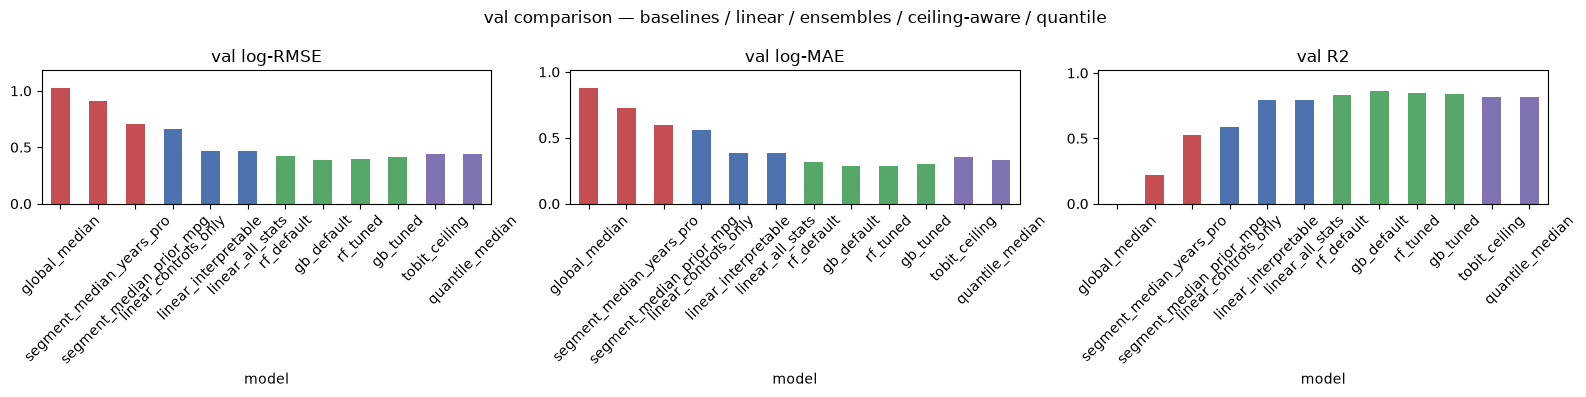

In [14]:
if RESULTS_CSV.exists():
    prev = pd.read_csv(RESULTS_CSV)
else:
    prev = pd.DataFrame(columns=res_new.columns)
res = pd.concat([prev, res_new], ignore_index=True)
res = res.drop_duplicates(subset=["model", "split"], keep="last")
res.to_csv(RESULTS_CSV, index=False)
print("wrote", RESULTS_CSV, res.shape)

order = ["global_median", "segment_median_years_pro", "segment_median_prior_mpg",
         "linear_controls_only", "linear_interpretable", "linear_all_stats",
         "rf_default", "gb_default", "rf_tuned", "gb_tuned",
         "tobit_ceiling", "quantile_median"]
order = [m for m in order if m in set(res["model"])]
val = res[res["split"] == "val"].set_index("model").loc[order]
print("\nval metrics (all models):")
print(val[["rmse", "mae", "r2", "rmse_dollars", "mae_dollars"]].round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in ((axes[0], "rmse", "val log-RMSE"),
                       (axes[1], "mae", "val log-MAE"),
                       (axes[2], "r2", "val R2")):
    colors = ["#C44E52" if m in ("global_median", "segment_median_years_pro",
                                 "segment_median_prior_mpg") else
              ("#4C72B0" if m.startswith("linear") else
               ("#55A868" if m.startswith(("rf", "gb")) else "#8172B3")) for m in order]
    val[col].plot.bar(ax=ax, color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, (val[col].max() * 1.15 if col != "r2" else 1.02))
fig.suptitle("val comparison — baselines / linear / ensembles / ceiling-aware / quantile")
fig.tight_layout()
plt.show()

## Takeaways

**Part A — ceiling:**
- The cap is thin: only 6 deals sit exactly at their AAV ceiling; the relative
  3% band admits 22 deals (15 train, 4 val, 3 test), all legitimate
  max-contract stars. The Tobit MLE shows whether accounting for that
  censoring changes the ceiling deals' predictions and the market coefficient
  (A5 table).
- A two-stage Heckman was declined: the Probit is near-separated (15 censored
  rows vs 59+1 regressors), the Hessian does not invert, and the inverse-Mills
  ratio is NaN — so no ρσ / p-value is reported (A4).

**Part B — intervals:**
- QuantReg coverage should be ≈ 80% on val; if it is too low while the naive
  gb residual interval is closer, the linear quantile function is
  misspecified for the tails and the benchmark wins (or vice versa).
- The [q10, q90] width comparison (log and $) is the honest cost of honesty:
  well-calibrated intervals are wider than naive symmetric ones when the
  conditional distribution is skewed (ceiling-star deals, capped q90).
- Quantile crossing: q10 < q50 < q90 fails on 13/1,180 rows (6 train / 4 val /
  3 test) — a known artifact of fitting each quantile independently; the
  affected intervals are re-ordered as [q10, q90] regardless.

**Context questions (now under de-censoring):** if the market-size coefficients
stay ≈ 0 across OLS / Tobit latent / Heckman latent while the team-quality
coefficient stays negative, both findings survive the cap-robustness check:
markets don't pay more, and good teams pay less.